# Notebook 4 — Exploratory Data Analysis (Training Set Only)

## Load training data only

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv("../artifacts/03_train.csv", parse_dates=[
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
])

train.shape

Matplotlib is building the font cache; this may take a moment.


(67529, 22)

**Note:** Loaded 67,529 training rows and 22 columns — matches the train 
file saved in Notebook 3. Working on this split only for the rest of the EDA.

## Data types, shape, and memory usage

In [2]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 67529 entries, 0 to 67528
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       67529 non-null  str           
 1   customer_id                    67529 non-null  str           
 2   order_status                   67529 non-null  str           
 3   order_purchase_timestamp       67529 non-null  datetime64[us]
 4   order_approved_at              67515 non-null  str           
 5   order_delivered_carrier_date   67528 non-null  str           
 6   order_delivered_customer_date  67529 non-null  datetime64[us]
 7   order_estimated_delivery_date  67529 non-null  datetime64[us]
 8   customer_unique_id             67529 non-null  str           
 9   customer_zip_code_prefix       67529 non-null  int64         
 10  customer_city                  67529 non-null  str           
 11  customer_state            

**Note:** 22 columns: 3 IDs (not useful as features directly), 3 date 
columns (parsed), 3 categorical columns (order_status, customer_city, 
customer_state — need encoding), numerical aggregated features (n_items, 
total_price, etc.), and the target is_late. A handful of columns have 
1-14 missing values — very minor, will decide how to handle them next. 
Note: order_approved_at and order_delivered_carrier_date are stored as 
text, not datetime — would need conversion if used later.

## Missing values in detail

In [3]:
missing = train.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

order_approved_at               14
order_delivered_carrier_date     1
total_payment_value              1
n_payment_installments           1
n_payment_methods                1
dtype: int64

**Note:** Missing values are minimal (1-14 rows out of 67,529, less than 
0.03%). Likely random data entry gaps, not a meaningful pattern related 
to lateness. Will handle with simple imputation in the feature engineering 
notebook — no special treatment needed.

## Numerical columns: statistics and distributions

In [4]:
numeric_cols = ["n_items", "total_price", "total_freight", "avg_price",
                 "n_unique_sellers", "n_unique_products", "total_payment_value",
                 "n_payment_installments", "n_payment_methods"]

train[numeric_cols].describe()

,n_items,total_price,total_freight,avg_price,n_unique_sellers,n_unique_products,total_payment_value,n_payment_installments,n_payment_methods
count,67529.000000,67529.000000,67529.000000,67529.000000,67529.000000,67529.000000,67528.000000,67528.000000,67528.000000
mean,1.142072,135.888797,22.245936,124.239070,1.012054,1.037702,158.173637,2.974559,1.024020
std,0.541640,205.194019,20.002594,185.659661,0.114815,0.222199,214.285757,2.755168,0.153111
min,1.000000,2.290000,0.000000,1.514286,1.000000,1.000000,10.070000,1.000000,1.000000
25%,1.000000,45.900000,14.100000,41.000000,1.000000,1.000000,61.630000,1.000000,1.000000
50%,1.000000,85.000000,16.790000,78.970000,1.000000,1.000000,104.190000,2.000000,1.000000
75%,1.000000,149.900000,23.700000,139.900000,1.000000,1.000000,175.500000,4.000000,1.000000
max,21.000000,13440.000000,1002.290000,6735.000000,5.000000,7.000000,13664.080000,24.000000,2.000000


**Note:** Most orders are simple (1 item, 1 seller, 1 product, 1 payment 
method), but price/freight/payment columns show strong right-skew — 
median total_price is 85 USD, but max is 13,440 USD. This means there are 
outliers (a few very expensive orders). Random Forest (planned model) 
handles this reasonably well without needing transformation, but this is 
worth keeping in mind.

## Visualize total_price distribution

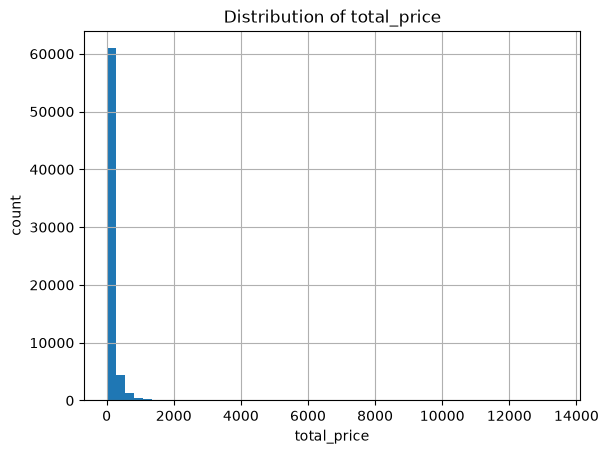

In [5]:
fig, ax = plt.subplots()
train["total_price"].hist(bins=50, ax=ax)
ax.set_title("Distribution of total_price")
ax.set_xlabel("total_price")
ax.set_ylabel("count")
plt.show()

**Note:** The histogram confirms the right-skew seen in the statistics — 
most orders are clustered at low prices, with a long thin tail of a few 
expensive orders extending to 14,000. This is typical for real-world 
purchase data and confirms outliers exist, but they are rare.

## Categorical columns: value counts and cardinality

In [6]:
print("Number of unique states:", train["customer_state"].nunique())
train["customer_state"].value_counts()

Number of unique states: 27


customer_state
SP    27204
RJ     8965
MG     8129
RS     3912
PR     3461
SC     2576
BA     2307
ES     1445
GO     1409
DF     1404
PE     1117
CE      948
PA      718
MT      640
MA      548
MS      502
PB      370
RN      349
PI      348
AL      298
SE      246
TO      197
RO      185
AM      105
AC       66
AP       51
RR       29
Name: count, dtype: int64

**Note:** 27 unique states, heavily dominated by SP (São Paulo) with ~40% 
of all orders. Several states have very few orders (RR: 29, AP: 51, AM: 105) 
— rare categories that could add noise with simple one-hot encoding. 
Will consider grouping rare states into "Other" during feature engineering.

## Late delivery rate by state

In [7]:
state_late_rate = train.groupby("customer_state")["is_late"].agg(["mean", "count"]).sort_values("mean", ascending=False)
state_late_rate

,mean,count
customer_state,,
AL,0.278523,298
MA,0.215328,548
CE,0.182489,948
RR,0.172414,29
SE,0.170732,246
PI,0.166667,348
RJ,0.165867,8965
BA,0.149978,2307
PA,0.133705,718


**Note:** customer_state shows a very strong relationship with is_late — 
late rate ranges from 3.8% (RO) to 27.9% (AL), a 7x difference. This 
confirms customer_state is likely an important feature. However, states 
with very few orders (RR: 29, AC: 66, AP: 51) have less reliable rates 
since they're based on small samples — reinforces the earlier idea of 
grouping rare states during feature engineering.

## Date patterns: weekday and month effects

In [8]:
train["purchase_weekday"] = train["order_purchase_timestamp"].dt.day_name()
train["purchase_month"] = train["order_purchase_timestamp"].dt.to_period("M")

train.groupby("purchase_weekday")["is_late"].mean().sort_values(ascending=False)

purchase_weekday
Monday       0.100149
Friday       0.094699
Tuesday      0.092646
Saturday     0.089688
Wednesday    0.086082
Sunday       0.083808
Thursday     0.082859
Name: is_late, dtype: float64

**Note:** Late rate by weekday is fairly flat (8.3% - 10.0%) — a small 
range compared to the 7x difference seen across states. Purchase weekday 
does not appear to be a strong predictor of lateness on its own, though 
it could still be included as a minor feature.

## Late rate by month (seasonality)

In [9]:
monthly = train.groupby("purchase_month")["is_late"].agg(["mean", "count"])
monthly

,mean,count
purchase_month,,
2016-09,1.000000,1
2016-10,0.011321,265
2016-12,0.000000,1
2017-01,0.030667,750
2017-02,0.032063,1653
2017-03,0.055774,2546
2017-04,0.078593,2303
2017-05,0.036107,3545
2017-06,0.038596,3135


**Note:** Clear seasonality/trend: late rate stayed around 3-8% through 
most of 2017, spiked to 14.3% in November 2017 (likely Black Friday 
demand), and spiked much higher to 16-21% in February-March 2018 — the 
highest rates in the entire dataset. This explains why train's overall 
late rate (9.0%) is higher than val (5.3%) and test (6.6%): the last 
few months of train include this unusual high-delay period. Worth 
flagging as a real pattern the model should try to capture (e.g., via 
month or seasonality features), not an error in the split.

## Delivery time vs estimated time

In [10]:
train["estimated_days"] = (train["order_estimated_delivery_date"] - train["order_purchase_timestamp"]).dt.days

train.groupby("is_late")["estimated_days"].mean()

is_late
0    24.302232
1    23.523294
Name: estimated_days, dtype: float64

**Note:** Estimated delivery window is nearly identical for late vs on-time 
orders (23.5 vs 24.3 days) — not a strong standalone predictor. The 
seasonality/month pattern and customer_state remain the stronger signals 
found so far.

## Summary of Findings and Feature Decisions

**Key findings:**
- Strong signal: `customer_state` — late rate ranges from 3.8% to 27.9% across states (7x difference)
- Strong signal: seasonality/month — late rate spiked to 16-21% in Feb-Mar 2018 vs 3-8% in most of 2017
- Weak signal: `purchase_weekday` — late rate nearly flat (8.3%-10.0%)
- Weak signal: `estimated_days` — nearly identical for late vs on-time orders
- Data quality: numerical columns (price, freight) are right-skewed with a few large outliers; handled fine by tree-based models
- Missing values are minimal (<0.03%) and not meaningful — safe to impute
- Rare categories exist in `customer_state` (e.g., RR: 29 orders) — consider grouping into "Other"

**Features planned for Notebook 5:**
- `n_items`, `total_price`, `total_freight`, `avg_price`, `n_unique_sellers`, `n_unique_products` (numerical, from order_items)
- `total_payment_value`, `n_payment_installments`, `n_payment_methods` (numerical, from payments)
- `customer_state` (categorical, one-hot encoded, rare states grouped)
- `purchase_month` (categorical or numerical, to capture seasonality)

**Model choice:** Tree-based model (Random Forest) — handles skewed numerical 
data and mixed feature types well without needing heavy transformation.

## Save key chart as artifact

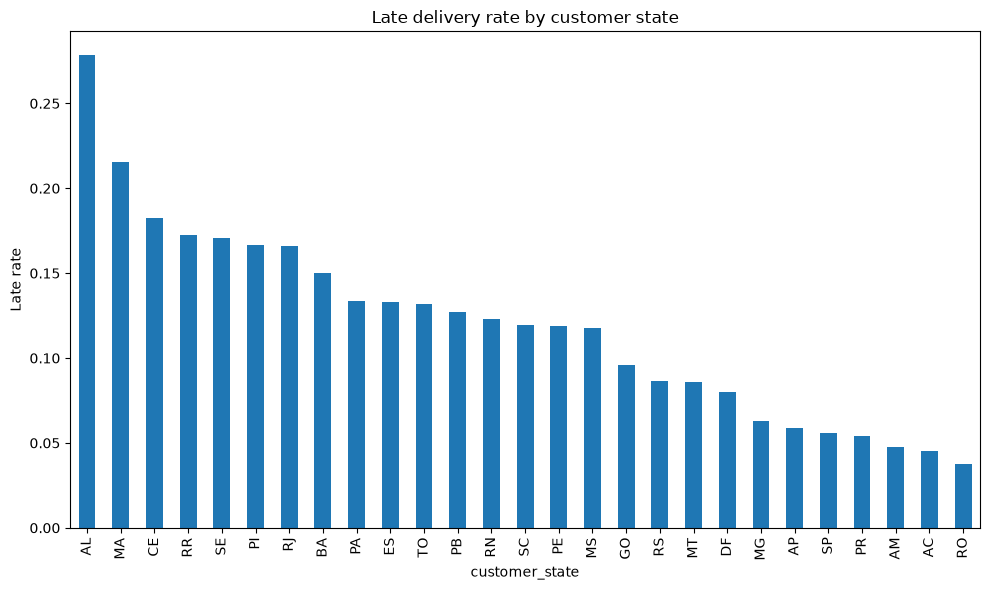

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
state_late_rate["mean"].sort_values(ascending=False).plot(kind="bar", ax=ax)
ax.set_title("Late delivery rate by customer state")
ax.set_ylabel("Late rate")
fig.tight_layout()
fig.savefig("../artifacts/04_late_rate_by_state.png")
plt.show()